# Baby GPT — Developmental Analysis

Tracks how the model develops over longer training horizons (5m → 15m → 30m → 1h → 2h → 4h → 8h → 12h).

Milestone eval + prompt-pack generation now happens **inside** `train.py` (see `_save_timed_checkpoint`), so no post-run CLI steps are needed — the notebook reads `model_<label>.json` sidecars and `progress.csv` directly from the latest run dir.

A prior-run overlay is supported via `BASELINE_DIR` in the next cell.

In [1]:
import json
import os
import re
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path
from IPython.display import display, Markdown

HERE = Path(".").resolve()
OUT = HERE / "output"


def _looks_like_run_dir(d: Path) -> bool:
    """A run dir contains training artifacts (checkpoint sidecars, progress.csv,
    or eval_results.csv). Excludes archive dirs and non-run scratch like exports/."""
    if d.name.startswith("_"):
        return False
    if (d / "progress.csv").exists() or (d / "eval_results.csv").exists():
        return True
    return any(d.glob("model_*.json"))


def _latest_run_dir():
    """Return the most recent run-dir subdir under output/.
    Sorted by mtime (most recently written run wins) with name as tiebreaker."""
    if not OUT.is_dir():
        return OUT
    candidates = [d for d in OUT.iterdir() if d.is_dir() and _looks_like_run_dir(d)]
    if not candidates:
        return OUT
    candidates.sort(key=lambda d: (d.stat().st_mtime, d.name), reverse=True)
    return candidates[0]


RUN_DIR = _latest_run_dir()
print(f"RUN_DIR: {RUN_DIR}")

# Optional baseline run to overlay against (yesterday's dedicated 5m-4h sweep).
BASELINE_DIR = OUT / "2026-04-17_phase2_baseline"
if not BASELINE_DIR.is_dir() or BASELINE_DIR == RUN_DIR:
    BASELINE_DIR = None
print(f"BASELINE: {BASELINE_DIR}")

LABELS = ["5m", "15m", "30m", "1h", "2h", "4h", "8h", "12h"]
LABEL_S = {
    "5m": 300,
    "15m": 900,
    "30m": 1800,
    "1h": 3600,
    "2h": 7200,
    "4h": 14400,
    "8h": 28800,
    "12h": 43200,
}
COLORS = [
    "#4e79a7",
    "#f28e2b",
    "#e15759",
    "#76b7b2",
    "#59a14f",
    "#b07aa1",
    "#ff9da7",
    "#9c755f",
]
COLOR_OF = {l: c for l, c in zip(LABELS, COLORS)}


def _eval_df_from_dir(run_dir):
    """Build the (label, elapsed_seconds, num_steps, train_loss_ema, val_bpb) table
    from JSON sidecars. Falls back to eval_results.csv if present and non-empty."""
    if run_dir is None or not Path(run_dir).is_dir():
        return pd.DataFrame()
    csv = Path(run_dir) / "eval_results.csv"
    if csv.exists():
        try:
            df = pd.read_csv(csv)
            if len(df) > 0:
                return df
        except Exception:
            pass
    rows = []
    for label in LABELS:
        meta = Path(run_dir) / f"model_{label}.json"
        if not meta.exists():
            continue
        try:
            d = json.loads(meta.read_text())
        except Exception:
            continue
        rows.append(
            {
                "label": label,
                "elapsed_seconds": d.get("elapsed_seconds"),
                "num_steps": d.get("num_steps"),
                "train_loss_ema": d.get("train_loss_ema"),
                "val_bpb": d.get("val_bpb"),
            }
        )
    return pd.DataFrame(rows)


plt.rcParams.update(
    {"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False}
)

RUN_DIR: C:\Dev\AI\Training\autoresearch\output\2026-04-19_2h_warmdown_0.90_run
BASELINE: C:\Dev\AI\Training\autoresearch\output\2026-04-17_phase2_baseline


## 1. Checkpoint Inventory

In [2]:
# Load JSON sidecars for all found checkpoints
rows = []
for label in LABELS:
    pt = RUN_DIR / f"model_{label}.pt"
    meta = RUN_DIR / f"model_{label}.json"
    if not pt.exists():
        continue
    d = {"label": label, "pt_size_mb": round(pt.stat().st_size / 1e6, 1)}
    if meta.exists():
        d.update(json.loads(meta.read_text()))
    rows.append(d)

inventory = pd.DataFrame(rows)
print(f"Found {len(inventory)} checkpoint(s)")
display(
    inventory[
        [
            c
            for c in [
                "label",
                "elapsed_seconds",
                "num_steps",
                "train_loss_ema",
                "val_bpb",
                "pt_size_mb",
            ]
            if c in inventory.columns
        ]
    ]
)

Found 5 checkpoint(s)


,label,elapsed_seconds,num_steps,train_loss_ema,val_bpb,pt_size_mb
0,5m,300.1,1443,3.512730,1.253732,90.2
1,15m,900.1,4331,3.378381,1.205067,90.2
2,30m,1800.1,8664,3.304161,1.177505,90.2
3,1h,3600.1,17328,3.223759,1.142390,90.2
4,2h,7200.2,34661,2.948463,1.050018,90.2


## 2. Developmental Curve — val_bpb & train loss vs time

,label,elapsed_seconds,num_steps,train_loss_ema,val_bpb,elapsed_min
0,5m,300.1,1443,3.512730,1.253732,5.001667
1,15m,900.1,4331,3.378381,1.205067,15.001667
2,30m,1800.1,8664,3.304161,1.177505,30.001667
3,1h,3600.1,17328,3.223759,1.142390,60.001667
4,2h,7200.2,34661,2.948463,1.050018,120.003333


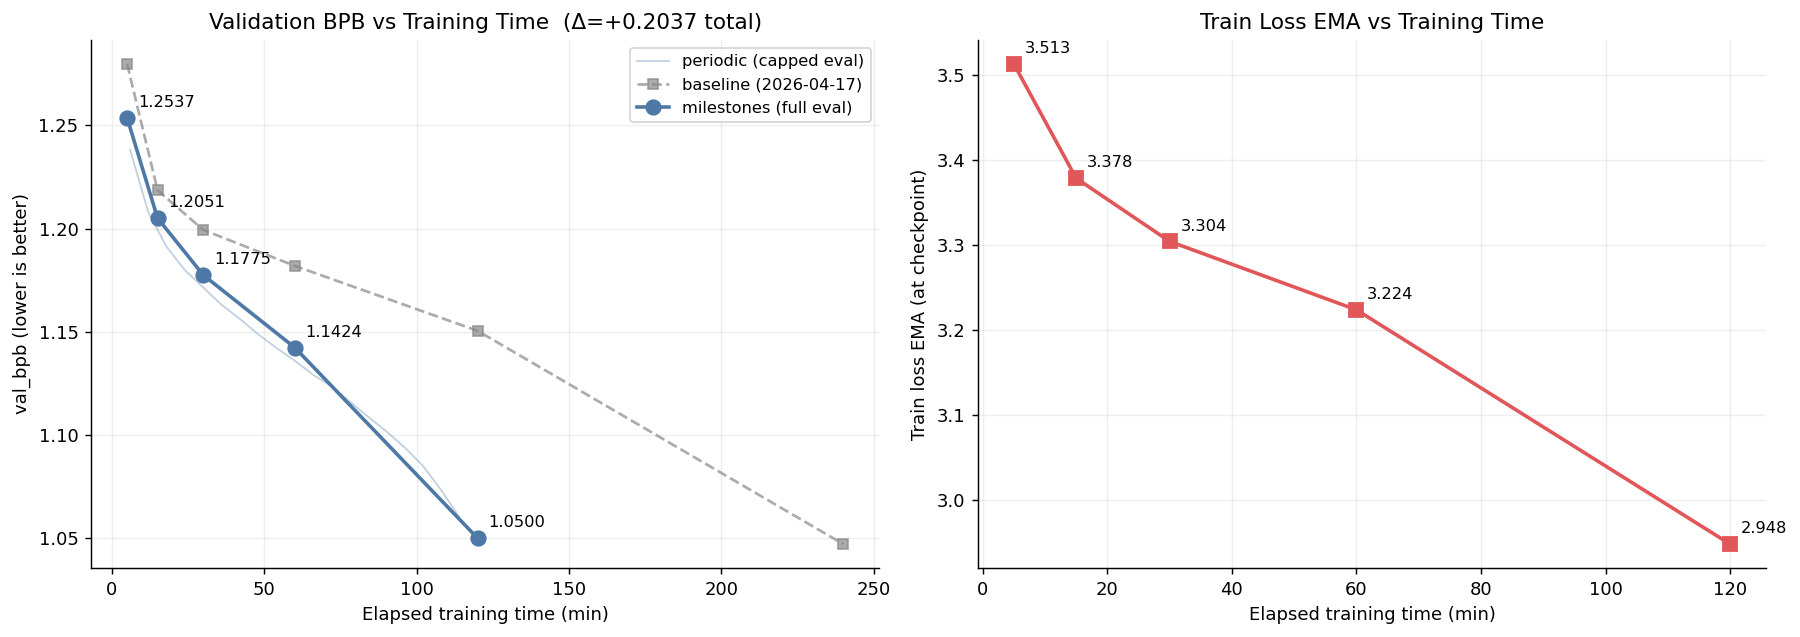

Saved output/developmental_curve.png


In [3]:
# Build eval_df from JSON sidecars (or eval_results.csv if present).
eval_df = _eval_df_from_dir(RUN_DIR)
if eval_df.empty:
    print("No milestone checkpoints found in RUN_DIR yet.")
else:
    eval_df["elapsed_min"] = (
        pd.to_numeric(eval_df["elapsed_seconds"], errors="coerce") / 60
    )
    eval_df["val_bpb"] = pd.to_numeric(eval_df["val_bpb"], errors="coerce")
    eval_df["train_loss_ema"] = pd.to_numeric(
        eval_df["train_loss_ema"], errors="coerce"
    )
    display(eval_df)

# Optional dense periodic curve (progress.csv) written by train.py every ~5% of progress.
progress_csv = RUN_DIR / "progress.csv"
progress_df = pd.read_csv(progress_csv) if progress_csv.exists() else pd.DataFrame()
if not progress_df.empty:
    progress_df["elapsed_min"] = (
        pd.to_numeric(progress_df["elapsed_seconds"], errors="coerce") / 60
    )
    progress_df["val_bpb_capped"] = pd.to_numeric(
        progress_df["val_bpb_capped"], errors="coerce"
    )

# Optional baseline for side-by-side overlay.
baseline_df = _eval_df_from_dir(BASELINE_DIR)
if not baseline_df.empty:
    baseline_df["elapsed_min"] = (
        pd.to_numeric(baseline_df["elapsed_seconds"], errors="coerce") / 60
    )
    baseline_df["val_bpb"] = pd.to_numeric(baseline_df["val_bpb"], errors="coerce")
    baseline_df["train_loss_ema"] = pd.to_numeric(
        baseline_df["train_loss_ema"], errors="coerce"
    )

if not eval_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- val_bpb ---
    ax = axes[0]
    # Dense periodic curve (capped eval) behind the milestone markers
    if not progress_df.empty:
        ax.plot(
            progress_df["elapsed_min"],
            progress_df["val_bpb_capped"],
            linewidth=1,
            color="#4e79a7",
            alpha=0.35,
            label="periodic (capped eval)",
        )
    # Optional baseline curve for comparison
    if not baseline_df.empty:
        ax.plot(
            baseline_df["elapsed_min"],
            baseline_df["val_bpb"],
            marker="s",
            linestyle="--",
            linewidth=1.5,
            color="#888",
            markersize=6,
            alpha=0.7,
            label="baseline (2026-04-17)",
        )
    ax.plot(
        eval_df["elapsed_min"],
        eval_df["val_bpb"],
        marker="o",
        linewidth=2,
        color="#4e79a7",
        markersize=8,
        label="milestones (full eval)",
    )
    for _, row in eval_df.iterrows():
        if pd.notna(row["val_bpb"]):
            ax.annotate(
                f"{row['val_bpb']:.4f}",
                (row["elapsed_min"], row["val_bpb"]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
            )
    ax.set_xlabel("Elapsed training time (min)")
    ax.set_ylabel("val_bpb (lower is better)")
    ax.set_title("Validation BPB vs Training Time")
    ax.grid(True, alpha=0.2)
    ax.legend(loc="upper right", fontsize=9)

    # Marginal improvement annotation
    bpb_vals = eval_df["val_bpb"].dropna().values
    if len(bpb_vals) >= 2:
        total_delta = bpb_vals[0] - bpb_vals[-1]
        ax.set_title(f"Validation BPB vs Training Time  (Δ={total_delta:+.4f} total)")

    # --- train loss EMA ---
    ax2 = axes[1]
    ax2.plot(
        eval_df["elapsed_min"],
        eval_df["train_loss_ema"],
        marker="s",
        linewidth=2,
        color="#e15759",
        markersize=8,
    )
    for _, row in eval_df.iterrows():
        if pd.notna(row["train_loss_ema"]):
            ax2.annotate(
                f"{row['train_loss_ema']:.3f}",
                (row["elapsed_min"], row["train_loss_ema"]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
            )
    ax2.set_xlabel("Elapsed training time (min)")
    ax2.set_ylabel("Train loss EMA (at checkpoint)")
    ax2.set_title("Train Loss EMA vs Training Time")
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(RUN_DIR / "developmental_curve.png", bbox_inches="tight")
    plt.show()
    print("Saved output/developmental_curve.png")

## 3. Marginal Returns — How Much Does Each Extra Hour Buy?

Marginal improvement per checkpoint:
label  elapsed_min  val_bpb  delta_bpb  bpb_per_min
   5m     5.001667 1.253732        NaN          NaN
  15m    15.001667 1.205067  -0.048665    -0.004866
  30m    30.001667 1.177505  -0.027562    -0.001837
   1h    60.001667 1.142390  -0.035115    -0.001171
   2h   120.003333 1.050018  -0.092372    -0.001539


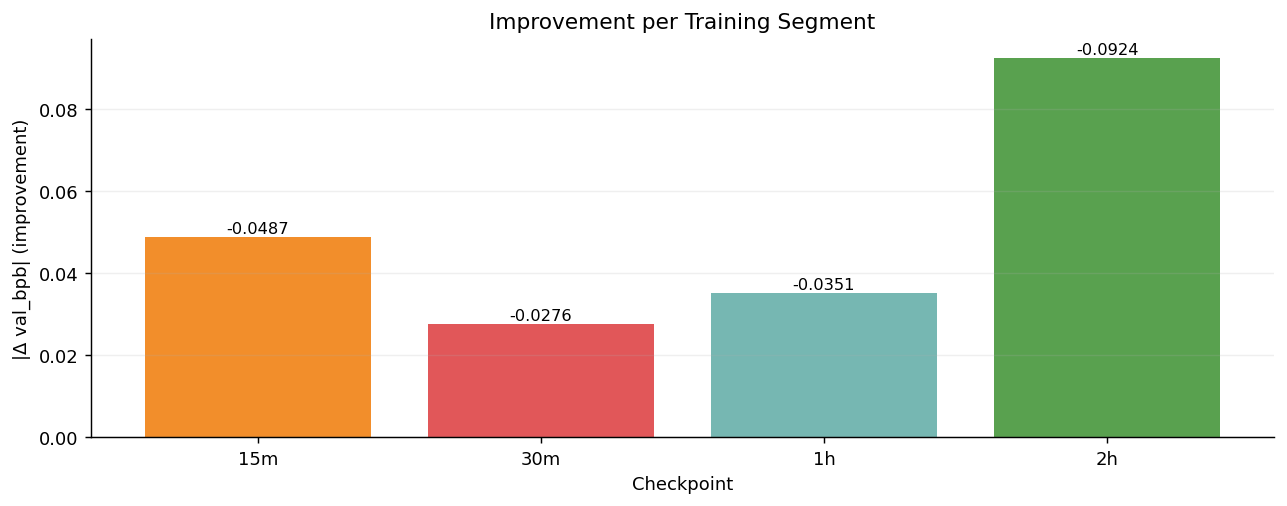

In [4]:
if not eval_df.empty and "val_bpb" in eval_df.columns:
    df = eval_df.dropna(subset=["val_bpb", "elapsed_min"]).copy()
    df["delta_bpb"] = df["val_bpb"].diff()  # change from previous checkpoint
    df["delta_min"] = df["elapsed_min"].diff()  # minutes between checkpoints
    df["bpb_per_min"] = df["delta_bpb"] / df["delta_min"]  # improvement rate

    print("Marginal improvement per checkpoint:")
    print(
        df[["label", "elapsed_min", "val_bpb", "delta_bpb", "bpb_per_min"]].to_string(
            index=False
        )
    )

    if len(df) >= 3:
        fig, ax = plt.subplots(figsize=(10, 4))
        valid = df.dropna(subset=["bpb_per_min"])
        bars = ax.bar(
            valid["label"],
            valid["delta_bpb"].abs(),
            color=[COLOR_OF.get(l, "#aaa") for l in valid["label"]],
        )
        ax.set_xlabel("Checkpoint")
        ax.set_ylabel("|Δ val_bpb| (improvement)")
        ax.set_title("Improvement per Training Segment")
        ax.grid(True, alpha=0.2, axis="y")
        for bar, (_, row) in zip(bars, valid.iterrows()):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0002,
                f"{row['delta_bpb']:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        plt.tight_layout()
        plt.savefig(RUN_DIR / "marginal_returns.png", bbox_inches="tight")
        plt.show()

## 4. LR Schedule Shape at Each Duration

Shows how the warmdown curve changes shape as total training time increases, using the current WARMDOWN_RATIO.

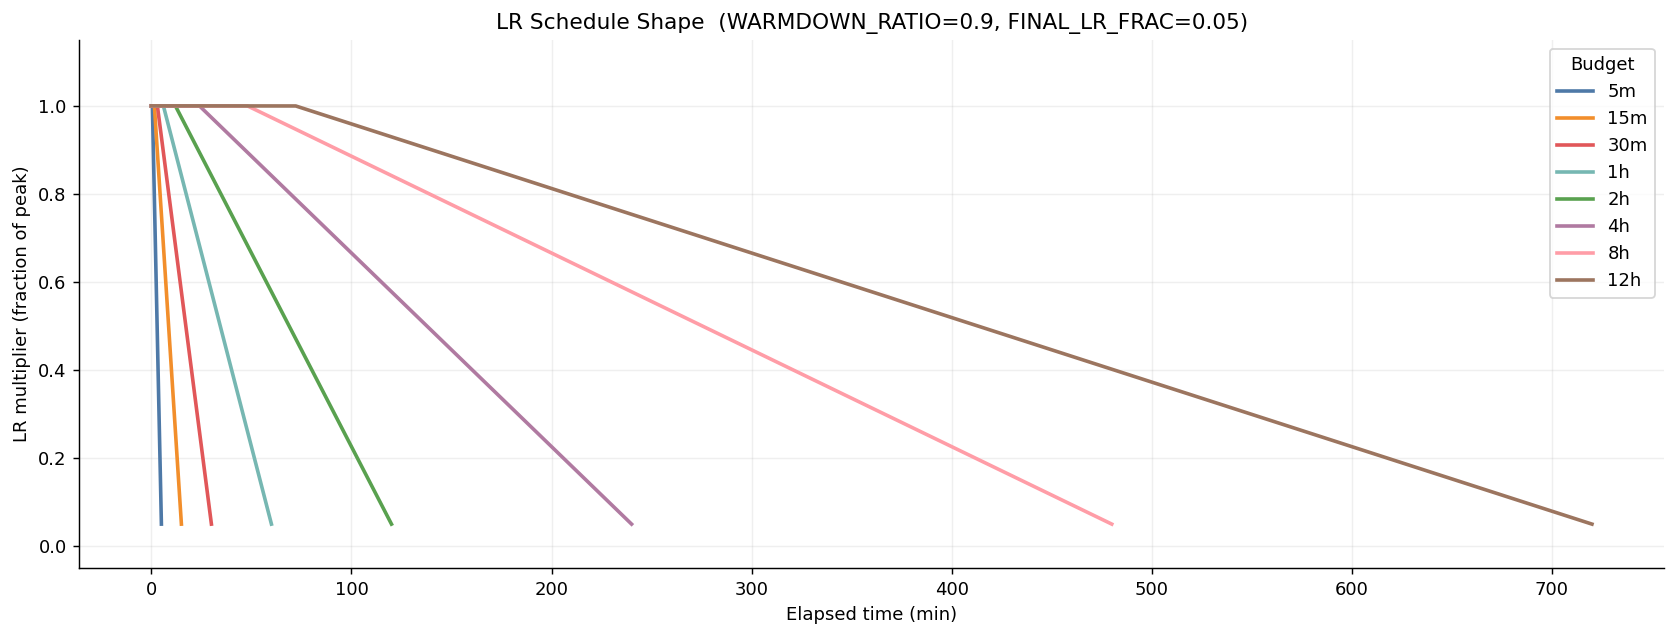

In [5]:
# Read current hyperparams from any available JSON sidecar
warmdown_ratio = 0.70
final_lr_frac = 0.05
for label in LABELS:
    meta_path = RUN_DIR / f"model_{label}.json"
    if meta_path.exists():
        m = json.loads(meta_path.read_text())
        hp = m.get("hyperparams", {})
        warmdown_ratio = hp.get("WARMDOWN_RATIO", warmdown_ratio)
        final_lr_frac = hp.get("FINAL_LR_FRAC", final_lr_frac)
        break


def lr_schedule(progress, warmdown_ratio=0.70, final_lr_frac=0.05, warmup_ratio=0.0):
    if progress < warmup_ratio:
        return progress / warmup_ratio if warmup_ratio > 0 else 1.0
    elif progress < 1.0 - warmdown_ratio:
        return 1.0
    else:
        cooldown = (1.0 - progress) / warmdown_ratio
        return cooldown + (1 - cooldown) * final_lr_frac


fig, ax = plt.subplots(figsize=(13, 5))
for label, color in zip(LABELS, COLORS):
    budget_s = LABEL_S[label]
    budget_m = budget_s / 60
    t = np.linspace(0, budget_m, 500)
    progress = t / budget_m
    lr = [lr_schedule(p, warmdown_ratio, final_lr_frac) for p in progress]
    ax.plot(t, lr, label=label, color=color, linewidth=2)

ax.set_xlabel("Elapsed time (min)")
ax.set_ylabel("LR multiplier (fraction of peak)")
ax.set_title(
    f"LR Schedule Shape  (WARMDOWN_RATIO={warmdown_ratio}, FINAL_LR_FRAC={final_lr_frac})"
)
ax.legend(title="Budget", loc="upper right")
ax.grid(True, alpha=0.2)
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.savefig(RUN_DIR / "lr_schedule.png", bbox_inches="tight")
plt.show()

## 5. Prompt Pack Outputs — Side-by-Side Comparison

In [6]:
PROMPT_NAMES = [
    "plain_continuation",
    "factual_fragment",
    "longitudinal_anchor",
    "structurally_awkward",
    "anomaly_lure",
    "signature",
    "continuation",
]


def parse_prompt_file(path):
    """Parse output/<label>_prompts.txt into a dict {prompt_name: completion_text}."""
    text = Path(path).read_text(encoding="utf-8")
    blocks = re.split(r"\n\[", text)
    results = {}
    for block in blocks[1:]:
        name_end = block.index("]")
        name = block[:name_end]
        body = block[name_end + 1 :]
        comp_match = re.search(r"COMPLETION:\s*(.*)", body, re.DOTALL)
        if comp_match:
            results[name] = comp_match.group(1).strip()
    return results


# Load all available prompt files
prompt_data = {}  # label -> {name -> text}
for label in LABELS:
    p = RUN_DIR / f"{label}_prompts.txt"
    if p.exists():
        try:
            prompt_data[label] = parse_prompt_file(p)
        except Exception as e:
            print(f"[{label}] could not parse: {e}")

print(f"Loaded prompt outputs for: {list(prompt_data.keys())}")

Loaded prompt outputs for: ['5m', '15m', '30m', '1h', '2h']


In [7]:
# Display side-by-side for each prompt type
available_labels = [l for l in LABELS if l in prompt_data]

for pname in PROMPT_NAMES:
    md = f"### `{pname}`\n\n"
    has_any = False
    for label in available_labels:
        text = prompt_data[label].get(pname, "*(not found)*")
        # Truncate for readability
        if len(text) > 600:
            text = text[:597] + "..."
        md += f"**{label}**\n> {text}\n\n"
        has_any = True
    if has_any:
        display(Markdown(md + "---"))

### `plain_continuation`

**5m**
> The old man walked slowly toward the river and has never been a difficult time driving by humans, but with a small range of human species and having the perfect balance in mind is a difficult time driving into the lives of a human. If we keep ourselves in check here, the only time you feel like we were here is when there is a whole process of uncheasing our brakes into our own city and here in the Greek world. The most important thing I am going to do is not to talk to them in any way. You want your brakes to be better then you will get brakes. My brakes are better than us for this to tell ...

**15m**
> The old man walked slowly toward the river and he was torn while still watching Dubai's break downward, watching the water and drinking in the rain. Already in the world, Dubai would not have had the chance to reach you because he couldn't be going through any other Dubai jaurs.
Dubai's breakdown at Peterot, and why Dubai said so in the world.

Question: What was the initial event of the trip? Answer: Peterot took over at Peterot, and why it did not have a chance to reach you because they did the trip?<|reserved_0|>If you had a 200 pic you just kept a tiny miniature miniature. You can fly o...

**30m**
> The old man walked slowly toward the river and flowing out for you in some very little bundles. You get you to think again, as soon as you turn to the river.
As the river continues to climb up, it's possible to think again.
It's not a fair idea to think that you've had a huge problem-solving for the river but the fact that you think of a river by hand, and is that in fact an easier way to see the people in some very close and clear waters as a side effect of what it is?
It could take a 24 hour for a man, or someone has a little background in the construction of the river.
Good idea; but don...

**1h**
> The old man walked slowly toward the river and drafted the river, the ancient lree loot, tower, tower, the river was as thick as it was in the loot, tower, or water. "Why does the ancient man walked slow and in some places?" It's not enough as a looter tower if it is buried in ancient lore. "The man walked slow and in some places it has been buried in the middle, but nevertheless it had its own, but it was a long way for you, to show up in this bible, it can be buried in ancient lore. There was some land along the Gulf of Stark where the great looter became the ones that had fallen past the...

**2h**
> The old man walked slowly toward the river and the man walked fast. It would have been quite difficult due to time when the man moved there and would walk almost instantly and take more than an hour of walk and the man was not an effective man to man. The man was the one man walked fast. I'm not worried, my man walking slowly and it looked like. Now I'm the old man walked, and I'm very careful when my man step back and my man walked.
To me this might be fun to tell your man how long after you walk, or do you have one man walking fast on the other side of it as long as the man walking slowly...

---

### `factual_fragment`

**5m**
> The capital of France is Paris, and the population of our chief, it is in danger to our owners and governments. It is also referred to as it is a group of people. The capital of France is defined as the first. It is formed by the name of the group of the capital of America. It is formed by the "game to be." The capital of Britain is formed by the 1910-1980s which the word "game" is actually "turned up" in the English language. The word translates to "long-legged capital" on English. It is originated in Tennon, France and the term "game to be' "Terrini," which is first defined in the English...

**15m**
> The capital of France is Paris, and the population of France, France, France and other other European countries, The Netherlands, Europe, Spain and Spain, the capital of South and South Southeast and the Czech.
Maintaining in the European Paris Against Eruption
The European Paris Against Eruption (EPAE) is a European agnap, and also by far the European Paris Against Eruption. European Paris Against Eruption. The Ecological Commission (EPAEC) shows no significant increase in the Eruption of European Paris Against Eruption.
This European settled France in her European Paris Against European P...

**30m**
> The capital of France is Paris, and the population of 150 has dropped to approximately 200 to 200. These 3rd-years range from 2000 to 2000, according to the population estimation of the economy.
What Are Policy Charseness (PRC)?
PRC and Paris Charseness, is a scientific and scientific literature on their subject and may not be perceived, according to the National Institute of Public Health, France.PRCs have been studied in two major categories:PRC and PRC. In this category, this is a scientific notation.PRICE SHIOLE
PRC, the Crisphere of the Universe, is the world’s biggest global force in ...

**1h**
> The capital of France is Paris, and the population of Paris is increasing. This year, the city was the first to be able to afford to acknowledge more than 6,600 people of Paris from around the world and to the country in the form of its own Paris, there. The city's first Paris project is called "Poiro de Newt," the public will likely give the poiro- tobacco, as well as the country's largest private, public and public fundraisons. Still, the urban infrastructure cost would be inadequate, the city is still in poorence and the country in Paris from the city has reached public fundraisons by th...

**2h**
> The capital of France is Paris, and the population of the Parisians is in Europe. Most of this, but the country is in France's Land
The Rise of Non-Korbigmans: Land as well as some of them cancel out. They can't be bought for sale. They can't be handed to other country
I was reading that one last thing about Paris and this is because I was very familiar with the idea of how the local government is able to stop them from getting there. There are many governments, some of these governments that stop their politics from being able to stop the people (even just that the political issues like th...

---

### `longitudinal_anchor`

**5m**
> In one sentence, the meaning of life is a term for the "life," refers to how a person has a connection to one when a person who has a negative impact in life is the life of someone’s most important life. When the person comes to life, or person’s life experiences, often experience a negative impact on one’s life. The last story is told by a man who has 6.15 people. When the person wants to see the life of life, the person he learies it, or does it feel a lost life. He is a personal and social, person, and a life acting on that thing. He is a personal, social and economic person.
Second book...

**15m**
> In one sentence, the meaning of life is lost in life and death by the beginning of a century, so the meaning of life is lost by the beginning of the year.

Looking at, there is a need to be in the life of the people in the world. In that way, people are doing a work, and they are doing a role (like a person sitting or watching TV) and simply sharing their opinions with their friends and family; and perhaps talking about people from different things. A person who has a life can be a person (humanity) that feels like a person, or is like a single person but who makes your work, work (these pe...

**30m**
> In one sentence, the meaning of life is that of a stone, another, or a quart, are actually a great example of someone else's strength. One piece of the stone is from the road it is a road where you get a chance of something. In a stone, it means you get a chance of something that someone thinks is it that you have an unprecedented relationship for which you've started it for just about 200 years and even 130 years old. If the stone has an unprecedented relationship (like stone). By that time you can ask that even more for the rest? Why is it possible to be a stone a piece of the road it use...

**1h**
> In one sentence, the meaning of life is intermined by those words. The reality is that life is connected to the soul, a person's stenciliating feeling so that they cannot exist, so they can, hence, be called life. For example, the life is divided into two groups: the same thing or the same as the same thing or the different thing: the same thing, and the opposite thing: the same in different ways. But things happen more and more so in the same way.

Of course, these same things are called life.

It is a term which refers to those of us who are wealth or who are just living in different ways...

**2h**
> In one sentence, the meaning of life is based on a particular meta-analysis. While it may seem to be similarly obvious, life is still too harsh to develop as you make progress. Many people who believe life is the most important thing. When you are thinking of living a long life, then life isn't always an answer to the question: ‪ Why is life and life important? ” ” ” Life as well as life is considered the most significant part of the global population. ‪ And life as well as life itself, there is much to learn, as well as a skill – as well as the ability to understand what things are. ” ” ” ...

---

### `structurally_awkward`

**5m**
> Despite the fact that however, the reason why because the fact that I actually told my dog is really wrong, isn't the only reason actually? We're actually the actual question of what's happening. We know when you read, if you read, the answer is your question with my answer. This is right, you will probably be the only question that I got the right question. That's not how science plays in mystical role, but also the fact that I have said to be a big reason for those who are trying to stand up, there is no way for me because I won't come away due to many of us, as we are now going to come a...

**15m**
> Despite the fact that however, the reason why because different colors are the size of the shell, most commonly called coloring, are not too smaller (mature, not too fussly or too large).
A smaller size of the shell means a 55x25x diameter. This means the shell must not be smaller. Because the larger shell the size of the shell, these large shells, called lilac shells, can take 12 to 24 mm, so the size is 2.
International Lily and Cockage
It is not just a large size shell. The shell must not be in a typical range of sizes, but also includes about 55x25 larger shells. Weight, large shells ca...

**30m**
> Despite the fact that however, the reason why because of the problem is because of its obvious limitations as well. The solution is to determine why the solution does not matter where the reason is that while the solution may have to be replaced by the solution. For example, for 9 years 2000 a while is probably 2 years old, or 3 months old if 1 years old, however, there are so many advantages to the solution. When was the solutions? You know they might be 3-4 years old.

Disadvantages

Good quality in its solution is not the reason. In order to determine why. First off, we do not need to lo...

**1h**
> Despite the fact that however, the reason why because it's true that the most important rule in the world is that if you have at least four tolls in the universe (or rather the way they could) you get to know it at least, to know that it's true that there is no rule or even no rule that in a number sense, there are no rule that in the universe. If it doesn't know or even just know that there are no rule, the truth about it is true but not even there. That is why it really matters most not because of no rule you can understand is true but even if you're not certain people are trying to disco...

**2h**
> Despite the fact that however, the reason why because of their poor eyesight. They never thought of the fact that we were all just like people, we could see some more about how we have come to believe in what is happening, and how and why it goes.

When I look back at the original question I came across, people have been saying "toucan" to me and I think "toucan" to go. When it comes to that question. While people have been saying they do nothing at all! Even though it's the fact that it's a fact, "touche" is a question of sorts and not a fact, but in many cases it becomes a fact and its a ...

---

### `anomaly_lure`

**5m**
> Ground control to Major Snorf, Cakery, Weather Rabbits
This beautifully reminds you of sageways to wrap into their mouths, not just not to do so, and that they actively support them. For most children, sageways, including adults, cats, cats, cats, cats, and some of their territorial nature. This is a particularly true source of connection to catacre and the importance of active nature.
Fortunately, adult cats are naturally echocrats, that their food is often raised as predators. Rabbits, including humans, are protected from pets from the environment and will develop their nuance. These cats...

**15m**
> Ground control to Major Snorf, Leechi, Rick, Shirmer
Ground control to Major snakes
Ground control should go on, but a snake should not be a very tallied snake's shoulders. You can also grow a snake's in some cases, while some snakes might be a small snake's shoulders. For example, the snake should have a strong curd shape, and in some cases, it is essential to provide a snake with a balanced curd shape.
To propagate through ground control should go through a snake-about. The snake should be tightly spatial to the base, between the shoulder, back and knee to the base with a horizontal elbow...

**30m**
> Ground control to Major Snorf, or a member of the masquis are common among allied Mother Nature and Division of Dahara Mandison's Mother Nature. If you have any questions on why you decide to go for an Mother Nature it's obvious that you have a choice between the species, the plants, or the flowers in this area and its habitats (even ground areas)—like birds in the Mother Nature.
While it's possible, a carnival of other Northwest Mother Nature's native plants, all their species like deer, praise, cucurus, melons!
The plant hosts insects at the surface of the leaf litter on the top of a gras...

**1h**
> Ground control to Major Snorf, Friendslit Mur. Sullivan. Ground control and home management. Uptake of earthquake control is a basic obligation for all civilians in the U.S., but no one knows. The rule is to get rid of all of these variables to the earthquake control of Mongolia, which includes more than 100,000 tonnes or about five percent of the total population of Mongolia. The rule is to obtain a ground control for Mongolia, as well as the earthquake control for Mongolians, such as the Mongolians and Sussex. So, to the extent that each Mongolian is different, it is a separate control of...

**2h**
> Ground control to Major Snorf, with its latest

Follow us on Twitter

Ground-balancing is an intriguing way of enhancing safety features in an upcoming, ever-loving NPR Senator.

NPR Sensing

Ground-balancing is the method of building smart, safe, comfortable clothing that has undergone advanced safety testing. Eco-friendly technology with its exceptional weather-fighting capabilities and advanced features make this innovative approach a must-have for every gamer. From safety features and accessories to its upgraded functionality and security features, this platform offers an extensive rang...

---

### `signature`

**5m**
> Once upon a time there was a small town among the residents, town, and tie, there lived a long range of about a 50s and two.
Robot (5) Dolphins, which lived at the 20th annual in Swiss. Unsynopsy. It seemed to have a very high visibility. It is a young houseplant. With friends being with friends or family and you have fun, a person could be on their own.
Cost About: 10th January
With the exceptional bird, there are 50 deaths for birds, including:
Today's birds. Many birds consume food. For more views, the bird is usually seen in birds. Dolphins. They eat food, as birds consume food. The bir...

**15m**
> Once upon a time there was a small population of Grayolaasaaaaaaaaa, he realized the idea is that they didn't do this. This "bad" is not a bad thing, either! However, as we may see the gay, we will have to go into something other than to put us on a table. One time he could see the gay, the smaller ones on the table. In our practice, we can study it, which shows it back into its habitual habit.
Now here, what does a superb or superconducting gay? The gay, we can expect one or the others to become too close to another person in his hand. So imagine, we wouldn't say they was just another indi...

**30m**
> Once upon a time there was a small town filled with airsoftware, there decided to start the Fabi, where the first thing looked and explained which things were different. This allowed me to join a conjunctiva (platinum, bolderos) where you wanted to share a real niche called a "citizative" or "picture."

On the two sides – Fabi was called a pintel, who was about two weeks later than Faul (they kept being on the right but he had to administer to a different representation). Sometimes the most common (after callo) was called a niche. But none went to the first place - you could see them at nig...

**1h**
> Once upon a time there was a small town nearby called a town called a Batanite town called Mesophiazstada. Batanas often live in quieter caveats known as mines. While some places might live on mines in search of mines, they have some great places for specialists who work to help discover valuable mines. Other places nearby may have a few miles off the coast of Sacramento.

There are some small town towns known as Mesophiazstada, and some places don't. They travel south for about three miles, most famous among the towns and cities of Batanite town miles. The town also plays tentatively by ma...

**2h**
> Once upon a time there was a small town called Latucci, lived two munitions, one of which became known as the Princes and the other a mad. The Princes had friends who loved sharing stories and stories about different cultures and cultures in different countries. However, as they weren't always there, these friends took part in learning about each other, especially among the people who made them feel loved sharing experiences and sharing stories.
One day, while browsing for more at first glance, browsing became an easy and fun way to explore the world around him. This included people who wer...

---

### `continuation`

**5m**
> The instructions were clear until line seven: In a quarter of quarter people have over half a millenthy quarter of their lives. Now the quarter is the quarter at the moment of my quarter. I do this twice for as long quarter quarter conversations I think as a quarter of people of quarter people have no quarter quarter quarter quarter questions. It seems to be the same as quarter quarter you think quarter quarter quarter quarter quarter s quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter quarter-quar...

**15m**
> The instructions were clear until line seven: 1, 2 and 3 seconds with a single time, and half on each 2. 2. 8.4 mins per day (19:00:00) and each 4.0 mins per day (30:7:00). Each 2. 2 hours of instruction (31 to 28 days +/3:00). The code is then compiled and written by the instruction in Joseph RAG.
WARONGINGINALEGEMATLITIESESESESTSTS
REDUCEER CHESEESESEESESESESESEESESTSESESESESESESESTSTSESTSTSTSTSTSTSESTSESTTSTSESTSESESESESTSTSTSTSOLTSESTTSTSTSTSTSTSTSTSTSTSTSTSTSESESTSTSESTSINGTSTSTSTSESTS

========================================================================

**30m**
> The instructions were clear until line seven: a light bulb is light bulb with a power meter - a red bulb is the red bulb with a voltage reading circuit: a fuse circuit is a light bulb that is not installed on it, like it's a light bulb; a LED will emit the bright red bulbs with a light bulb. The compact bulb, or green bulb is light bulb, is a bulbous bulb that is used for many applications. It also produces the bright red bulb of any light bulb or a bulbous bulb that is not connected to the bulbs. The light bulb is responsible for a light bulb that includes light bulbs and lights, and the l...

**1h**
> The instructions were clear until line seven:19 the Egyptian Government established the same idea. In 1992 the Persians were established in England, but only in Europe and the first United States were still accepted until the 1972 Persian. The Persian was named Baptism, the Bible which had only 8.5 stars and 14 of which were first seen as the first to see a paleo-centre life. The Great Persian, who took a family traded the Persians to the Persian, reached Europe by 0.5 million years of age. It was founded by John H. Baptism, who the Bible was among the biggest German citizens in the 1840s, ...

**2h**
> The instructions were clear until line seven: A. Dungan

B. Gerald F. Crick

C. Ford

Answer: B. Dungan

D. Lloyd

D. Jamie G. Rick

Answer: C

Lewis Armit

Answer: G Rick

D. Ford

Answer: B. Dungan

Answer: C

H

Lewis Armit

Answer: B

Lewis Armit

Answer: L

Hewis Armit

Answer: H

Lewis Armit

Answer: H

Hewis Armit

Answer: H

Lewis Armit

Answer: B

Lewis Armit

Answer: H

Lewis Armit

Answer: H

Lewis Armit

Answer: H

Hewis Armit

Answer: H

Lewis Armit

Answer: Her

Her

Hewitzing

 questions

========================================================================

---

In [8]:
# Render prompt outputs to <run_dir>/prompts.md for out-of-notebook browsing.
# Raw <milestone>_prompts.txt files remain the source of truth; this is a
# regenerated markdown view matching Section 5's layout (no truncation).
#
# Completions render as markdown blockquotes (each line prefixed with '> ')
# so the preview wraps text naturally. _render_sweep_prompts_md is defined
# here so Section 8.7 can reuse it.


def _as_blockquote(text):
    """Prefix every line with '> ' so the text renders as a blockquote in
    markdown. Empty lines become '>' (blockquote continuation marker)."""
    lines = text.splitlines() or [""]
    return "\n".join(f"> {line}" if line.strip() else ">" for line in lines)


def _render_prompts_md(run_dir, labels, prompt_names, truncate=None):
    """Per-run markdown: grouped by prompt name, all milestones stacked."""
    run_dir = Path(run_dir)
    lines = [f"# Prompt outputs --- `{run_dir.name}`", ""]
    for meta in sorted(run_dir.glob("model_*.json")):
        try:
            d = json.loads(meta.read_text())
            hp = d.get("hyperparams", {})
            if "WARMDOWN_RATIO" in hp:
                lines.append(f"WARMDOWN_RATIO={hp['WARMDOWN_RATIO']}")
                lines.append("")
                break
        except Exception:
            continue

    loaded = {}
    for label in labels:
        p = run_dir / f"{label}_prompts.txt"
        if p.exists():
            try:
                loaded[label] = parse_prompt_file(p)
            except Exception:
                pass

    for pname in prompt_names:
        lines.append(f"## `{pname}`")
        lines.append("")
        any_shown = False
        for label in labels:
            if label not in loaded or pname not in loaded[label]:
                continue
            text = loaded[label][pname]
            if truncate and len(text) > truncate:
                text = text[: truncate - 3] + "..."
            lines.append(f"**{label}**")
            lines.append("")
            lines.append(_as_blockquote(text))
            lines.append("")
            any_shown = True
        if not any_shown:
            lines.append("_no data_")
            lines.append("")
    return "\n".join(lines)


def _render_sweep_prompts_md(run_dirs, labels, prompt_names, ratio_of, truncate=None):
    """Cross-run markdown: grouped prompt name -> milestone -> ratio."""
    ordered = sorted(
        run_dirs, key=lambda d: (ratio_of(d) if ratio_of(d) is not None else 999)
    )
    lines = ["# Sweep prompt outputs", ""]
    lines.append("Runs (ordered by ratio):")
    lines.append("")
    for d in ordered:
        r = ratio_of(d)
        lines.append(f"- `{Path(d).name}` --- WARMDOWN_RATIO={r}")
    lines.append("")

    data = {}
    for d in ordered:
        data[Path(d).name] = {}
        for label in labels:
            p = Path(d) / f"{label}_prompts.txt"
            if p.exists():
                try:
                    data[Path(d).name][label] = parse_prompt_file(p)
                except Exception:
                    pass

    for pname in prompt_names:
        lines.append(f"## `{pname}`")
        lines.append("")
        for label in labels:
            has_any = any(
                label in data[Path(d).name] and pname in data[Path(d).name][label]
                for d in ordered
            )
            if not has_any:
                continue
            lines.append(f"### {label}")
            lines.append("")
            for d in ordered:
                d_data = data[Path(d).name]
                if label not in d_data or pname not in d_data[label]:
                    continue
                r = ratio_of(d)
                text = d_data[label][pname]
                if truncate and len(text) > truncate:
                    text = text[: truncate - 3] + "..."
                lines.append(f"**WARMDOWN_RATIO={r}**")
                lines.append("")
                lines.append(_as_blockquote(text))
                lines.append("")
    return "\n".join(lines)


_run_prompts_md = _render_prompts_md(RUN_DIR, LABELS, PROMPT_NAMES, truncate=None)
(RUN_DIR / "prompts.md").write_text(_run_prompts_md, encoding="utf-8")
print(f"Wrote: {RUN_DIR / 'prompts.md'}  ({len(_run_prompts_md):,} chars)")

Wrote: C:\Dev\AI\Training\autoresearch\output\2026-04-19_2h_warmdown_0.90_run\prompts.md  (30,437 chars)


## 6. Text Quality Metrics

Automatic proxies for qualitative change. These are rough signals, not ground truth.

Mean across all prompts per checkpoint:


,rep_onset_word,clean_span,rep_rate,sent_completion,ttr,avg_sent_len
label,,,,,,
5m,92.429,92.429,0.040,0.869,0.509,19.143
15m,59.000,59.000,0.025,0.869,0.552,16.486
30m,129.000,129.000,0.006,0.857,0.510,20.629
1h,91.143,91.143,0.013,0.852,0.511,20.329
2h,111.286,111.286,0.049,0.880,0.532,18.214


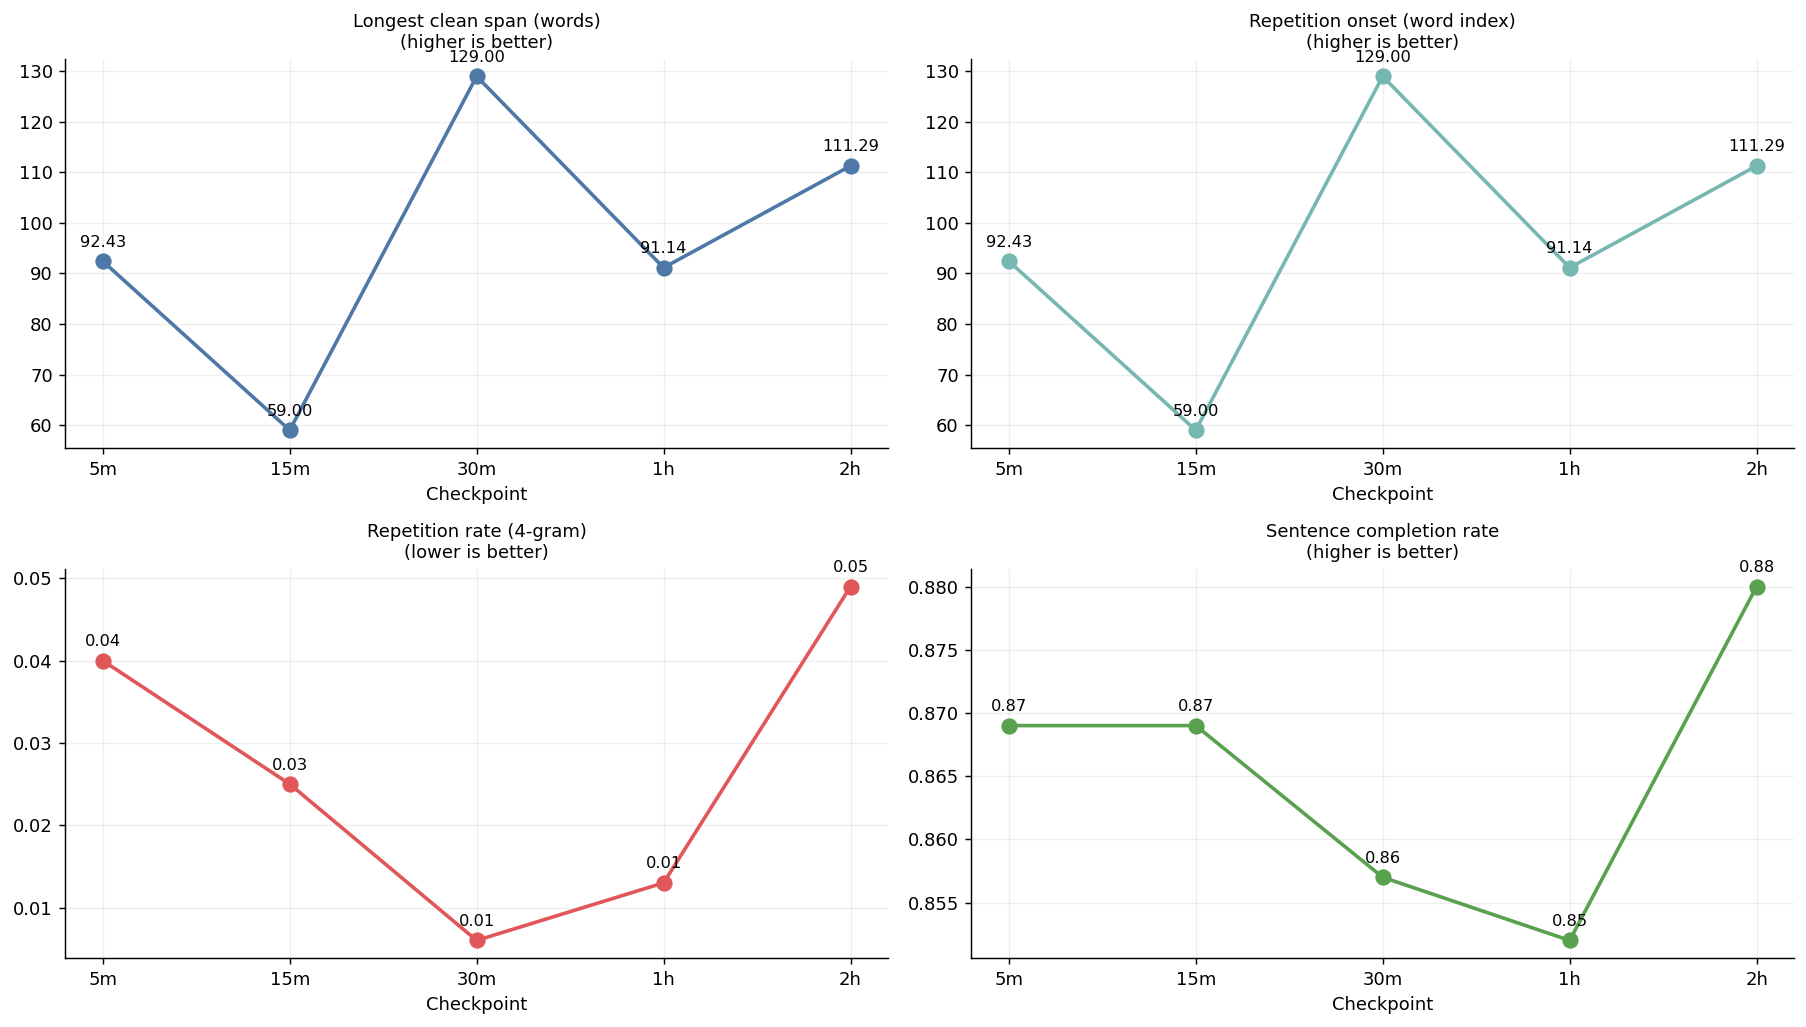

Saved output/text_metrics.png


In [9]:
def repetition_onset(text, ngram=4):
    """Word index of the first repeated n-gram. Returns None if no repetition."""
    words = text.lower().split()
    seen = {}
    for i in range(len(words) - ngram + 1):
        g = tuple(words[i : i + ngram])
        if g in seen:
            return i
        seen[g] = i
    return None


def longest_clean_span(text, ngram=4):
    """Number of words before the first repeated n-gram (= repetition_onset, or full length)."""
    onset = repetition_onset(text, ngram)
    words = text.split()
    return onset if onset is not None else len(words)


def repetition_rate(text, ngram=4):
    """Fraction of n-grams that are repeated."""
    words = text.lower().split()
    if len(words) < ngram + 1:
        return 0.0
    grams = [tuple(words[i : i + ngram]) for i in range(len(words) - ngram + 1)]
    return 1 - len(set(grams)) / len(grams)


def sentence_completion_rate(text):
    """Fraction of sentence-like units ending with . ! ? — proxy for syntactic tidiness."""
    units = re.split(r"(?<=[.!?])\s+", text.strip())
    if not units:
        return 0.0
    complete = sum(1 for u in units if re.search(r"[.!?]$", u.strip()))
    return complete / len(units)


def type_token_ratio(text):
    """Lexical diversity — length-dependent; use as directional signal only."""
    words = re.findall(r"\b\w+\b", text.lower())
    return len(set(words)) / len(words) if words else 0.0


def avg_sentence_length(text):
    sentences = re.split(r"[.!?]+", text)
    lengths = [len(s.split()) for s in sentences if s.strip()]
    return np.mean(lengths) if lengths else 0.0


# Compute metrics per label per prompt
metric_rows = []
for label in available_labels:
    for pname, text in prompt_data[label].items():
        onset = repetition_onset(text)
        metric_rows.append(
            {
                "label": label,
                "prompt": pname,
                "rep_onset_word": onset if onset is not None else len(text.split()),
                "clean_span": longest_clean_span(text),
                "rep_rate": round(repetition_rate(text), 4),
                "sent_completion": round(sentence_completion_rate(text), 3),
                "ttr": round(type_token_ratio(text), 4),
                "avg_sent_len": round(avg_sentence_length(text), 1),
            }
        )

if metric_rows:
    mdf = pd.DataFrame(metric_rows)
    summary = (
        mdf.groupby("label")[
            [
                "rep_onset_word",
                "clean_span",
                "rep_rate",
                "sent_completion",
                "ttr",
                "avg_sent_len",
            ]
        ]
        .mean()
        .round(3)
    )
    summary = summary.reindex([l for l in LABELS if l in summary.index])
    print("Mean across all prompts per checkpoint:")
    display(summary)

    # Plot: the four most diagnostic signals
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    plots = [
        ("clean_span", "Longest clean span (words)", "#4e79a7", "higher is better"),
        (
            "rep_onset_word",
            "Repetition onset (word index)",
            "#76b7b2",
            "higher is better",
        ),
        ("rep_rate", "Repetition rate (4-gram)", "#e15759", "lower is better"),
        ("sent_completion", "Sentence completion rate", "#59a14f", "higher is better"),
    ]
    for ax, (col, title, color, note) in zip(axes.flat, plots):
        ax.plot(
            summary.index,
            summary[col],
            marker="o",
            color=color,
            linewidth=2,
            markersize=8,
        )
        for x, y in zip(summary.index, summary[col]):
            ax.annotate(
                f"{y:.2f}",
                (x, y),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
            )
        ax.set_title(f"{title}\n({note})", fontsize=10)
        ax.set_xlabel("Checkpoint")
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(RUN_DIR / "text_metrics.png", bbox_inches="tight")
    plt.show()
    print("Saved output/text_metrics.png")

## 7. Qualitative Notes

Per-run scoring tables and narrative observations now live next to the run data, in `<run_dir>/qual-notes.md`. The rolling cross-run analysis (plateau evidence, warmdown findings, decisions for the next night) stays in [`docs/phase2-developmental-study.md`](docs/phase2-developmental-study.md). Memorable generations are collected in [`docs/curios.md`](docs/curios.md).

The current run's `qual-notes.md` is rendered below; if `BASELINE_DIR` has one, it is shown too for side-by-side comparison. If a run has no `qual-notes.md` yet, the cell prints a short hint instead.


In [10]:
def _show_qual_notes(run_path, heading):
    notes = Path(run_path) / "qual-notes.md"
    if not notes.is_file():
        display(Markdown(f"_No `qual-notes.md` in `{run_path.name}` yet._"))
        return
    display(Markdown(f"### {heading} — `{run_path.name}`"))
    display(Markdown(notes.read_text(encoding="utf-8")))


_show_qual_notes(RUN_DIR, "Current run")
if BASELINE_DIR is not None:
    _show_qual_notes(BASELINE_DIR, "Baseline")

### Current run — `2026-04-19_2h_warmdown_0.90_run`

# Qualitative notes --- `2026-04-19_2h_warmdown_0.90_run`

WARMDOWN_RATIO=0.9 · final val_bpb=1.0500

> Auto-generated first-pass scores. Objective columns (coherent span, repetition, syntax) derived from heuristics; subjective columns (specificity, interest, prompt adherence, weirdness) left blank --- fill when inspired. Override any cell freely; regenerate with `python scripts/gen_qual_notes.py <run_dir>` to refresh only the objective columns (user edits to subjective columns will be overwritten on re-run, so commit before regenerating).

## Scoring

Scales: **coherent span** 1 (poor) -> 5 (excellent) · **repetition** none / late / medium / early · **syntax** poor / mixed / good · **specificity** specific / generic / filler · **interest** 1--5 · **prompt adherence** follows / drifts / ignores · **weirdness** high / balanced / sterilized

| Milestone | Coherent span | Repetition | Syntax | Specificity | Interest | Prompt adherence | Weirdness |
| --- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 5m | 3 | medium | good | | | | |
| 15m | 3 | medium | good | | | | |
| 30m | 3 | medium | good | | | | |
| 1h | 3 | medium | good | | | | |
| 2h | 3 | late | good | | | | |

## Heuristic detail (objective signals behind the table)

| Milestone | mean lex-div | mean non-ascii frac | mean len (words) | rep-onset / N | repetition rate |
| --- | ---: | ---: | ---: | :---: | ---: |
| 5m | 0.558 | 0.0008 | 156 | 71/156 | 0.71 |
| 15m | 0.601 | 0.0000 | 135 | 40/135 | 0.71 |
| 30m | 0.559 | 0.0007 | 160 | 70/160 | 0.29 |
| 1h | 0.547 | 0.0002 | 153 | 71/153 | 0.71 |
| 2h | 0.573 | 0.0024 | 151 | 80/151 | 0.57 |

## User notes

_Free-form observations. Fill when inspired._

## Curios hints

_Completions worth promoting to [`docs/curios.md`](../../docs/curios.md). Format: `- <milestone> `<prompt_name>` --- brief note`._



_No `qual-notes.md` in `2026-04-17_phase2_baseline` yet._

## 8. Phase 2c --- Warmdown Sweep Overlay

Cross-run analysis over `SWEEP_DIRS`. Independent of sections 1--7 (which operate on a single `RUN_DIR`); this section aggregates across all runs of a sweep.

Defaults to auto-detecting any `output/*_warmdown_*_run` dirs. Override by setting `SWEEP_DIRS = [...]` manually. If empty, Section 8 skips with a short note.

Artifacts written:

- PNG plots into the sweep parent dir (`output/<sweep-parent>/*.png`)
- `prompts.md` cross-run prompt overlay into the sweep parent
- Per-run `prompts.md` refreshed in each sweep child

See [`docs/workflow.md`](docs/workflow.md) for the folder-structure conventions.

### 8.1 Sweep config + loader

In [11]:
# ---- 8.1 Sweep config + loader ----
# Auto-detect sweep dirs; parameter-agnostic loader. Works for any sweep dir
# matching the pattern, not just warmdown. See docs/workflow.md.

_RATIO_RE = re.compile(r"_(\d+(?:\.\d+)?)_run$")


def _detect_sweep_dirs(pattern="*_warmdown_*_run"):
    if not OUT.is_dir():
        return []
    return sorted(OUT.glob(pattern))


def _ratio_from_run_dir(run_dir):
    """Prefer WARMDOWN_RATIO in model_*.json; fall back to parsing the dir name."""
    run_dir = Path(run_dir)
    for meta in sorted(run_dir.glob("model_*.json")):
        try:
            d = json.loads(meta.read_text())
            hp = d.get("hyperparams", {})
            if "WARMDOWN_RATIO" in hp:
                return float(hp["WARMDOWN_RATIO"])
        except Exception:
            continue
    m = _RATIO_RE.search(run_dir.name)
    return float(m.group(1)) if m else None


def _sweep_parent_dir(sweep_dirs):
    """Find a cohabiting '<date>_..._sweep_*' parent dir for the given children."""
    if not sweep_dirs:
        return None
    date = Path(sweep_dirs[0]).name.split("_")[0]
    candidates = sorted(OUT.glob(f"{date}_*_sweep_*"))
    return candidates[0] if candidates else None


def load_runs(run_dirs):
    """Long-format DataFrame: (run_label, ratio, milestone, progress,
    elapsed_seconds, val_bpb, lr_mult, train_loss_ema, source).
    'source' is 'progress' (dense, capped eval) or 'milestone' (uncapped)."""
    frames = []
    for rd in run_dirs:
        rd = Path(rd)
        ratio = _ratio_from_run_dir(rd)
        prog = rd / "progress.csv"
        if prog.exists():
            try:
                pdf = pd.read_csv(prog)
                pdf = pdf.rename(columns={"val_bpb_capped": "val_bpb"})
                pdf["run_label"] = rd.name
                pdf["ratio"] = ratio
                pdf["source"] = "progress"
                pdf["milestone"] = None
                frames.append(pdf)
            except Exception:
                pass
        mdf = _eval_df_from_dir(rd)
        if not mdf.empty:
            mdf["run_label"] = rd.name
            mdf["ratio"] = ratio
            mdf["source"] = "milestone"
            mdf["milestone"] = mdf["label"]
            total = mdf["elapsed_seconds"].max()
            mdf["progress"] = mdf["elapsed_seconds"] / total if total else None
            mdf["lr_mult"] = np.nan
            frames.append(mdf)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False)


def _ratio_color(ratio):
    """Cool->warm gradient; more warmdown = warmer color."""
    import matplotlib.colors as mc

    try:
        import matplotlib

        cmap = matplotlib.colormaps["coolwarm"]
    except (AttributeError, KeyError):
        from matplotlib import cm

        cmap = cm.get_cmap("coolwarm")
    x = max(0.0, min(1.0, ratio if ratio is not None else 0.5))
    return mc.to_hex(cmap(x))


SWEEP_DIRS = _detect_sweep_dirs()
SWEEP_PARENT = _sweep_parent_dir(SWEEP_DIRS)

if SWEEP_DIRS:
    print(f"SWEEP_DIRS ({len(SWEEP_DIRS)}):")
    for d in SWEEP_DIRS:
        print(f"  {d.name}  (ratio={_ratio_from_run_dir(d)})")
    print(f"SWEEP_PARENT: {SWEEP_PARENT}")
    sweep_df = load_runs(SWEEP_DIRS)
    print(
        f"Loaded {len(sweep_df):,} rows ({(sweep_df['source']=='progress').sum()} dense + "
        f"{(sweep_df['source']=='milestone').sum()} milestone)."
    )
else:
    print("No sweep dirs matched output/*_warmdown_*_run. Section 8 will skip.")
    sweep_df = pd.DataFrame()

SWEEP_DIRS (4):
  2026-04-19_2h_warmdown_0.30_run  (ratio=0.3)
  2026-04-19_2h_warmdown_0.50_run  (ratio=0.5)
  2026-04-19_2h_warmdown_0.70_run  (ratio=0.7)
  2026-04-19_2h_warmdown_0.90_run  (ratio=0.9)
SWEEP_PARENT: C:\Dev\AI\Training\autoresearch\output\2026-04-19_warmdown_sweep_2h
Loaded 96 rows (76 dense + 20 milestone).


### 8.2 Overlaid val_bpb curves

Primary comparison. Dense `progress.csv` curves plus milestone (uncapped) eval points. Baseline overlay on by default; set `OVERLAY_BASELINE = False` to hide.

Saved: C:\Dev\AI\Training\autoresearch\output\2026-04-19_warmdown_sweep_2h\sweep_val_bpb_curves.png


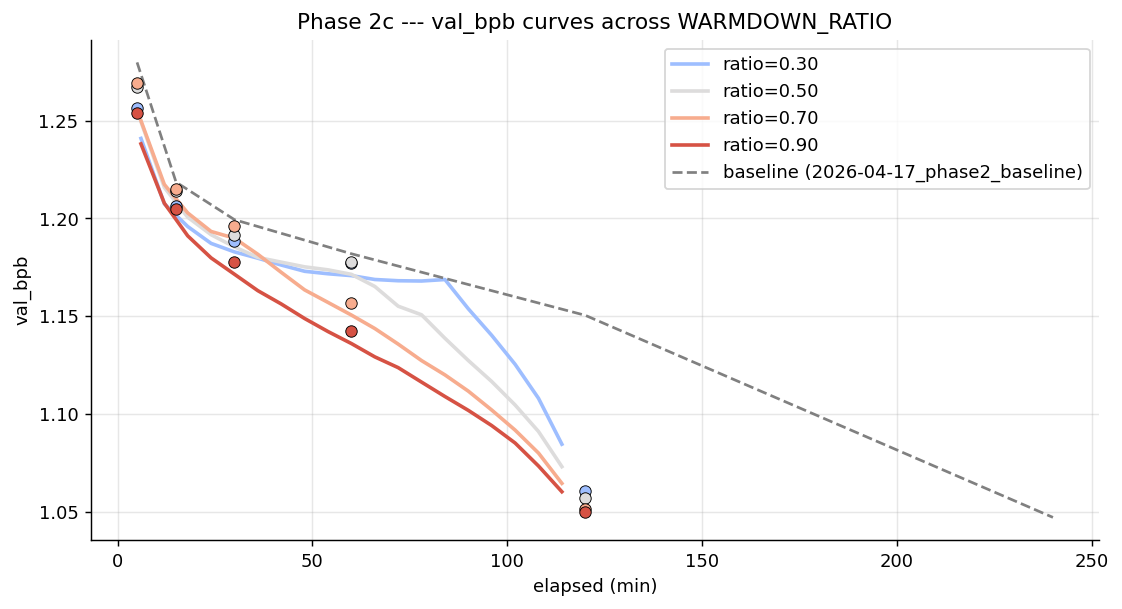

In [12]:
OVERLAY_BASELINE = True

if sweep_df.empty:
    print("Skipping 8.2: no sweep data.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    prog_df = sweep_df[sweep_df["source"] == "progress"]
    ms_df = sweep_df[sweep_df["source"] == "milestone"]
    ratios = sorted(prog_df["ratio"].dropna().unique())

    for r in ratios:
        sub = prog_df[prog_df["ratio"] == r].sort_values("elapsed_seconds")
        ax.plot(
            sub["elapsed_seconds"] / 60,
            sub["val_bpb"],
            label=f"ratio={r:.2f}",
            color=_ratio_color(r),
            linewidth=2,
        )
        ms = ms_df[ms_df["ratio"] == r]
        ax.scatter(
            ms["elapsed_seconds"] / 60,
            ms["val_bpb"],
            color=_ratio_color(r),
            marker="o",
            s=40,
            edgecolor="black",
            linewidth=0.5,
            zorder=5,
        )

    if OVERLAY_BASELINE and BASELINE_DIR is not None:
        bdf = _eval_df_from_dir(BASELINE_DIR)
        if not bdf.empty and "val_bpb" in bdf.columns:
            bdf = bdf.dropna(subset=["val_bpb", "elapsed_seconds"]).sort_values(
                "elapsed_seconds"
            )
            ax.plot(
                bdf["elapsed_seconds"] / 60,
                bdf["val_bpb"],
                color="gray",
                linestyle="--",
                linewidth=1.5,
                label=f"baseline ({BASELINE_DIR.name})",
                zorder=3,
            )

    ax.set_xlabel("elapsed (min)")
    ax.set_ylabel("val_bpb")
    ax.set_title("Phase 2c --- val_bpb curves across WARMDOWN_RATIO")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if SWEEP_PARENT is not None:
        plt.savefig(SWEEP_PARENT / "sweep_val_bpb_curves.png", bbox_inches="tight")
        print(f"Saved: {SWEEP_PARENT / 'sweep_val_bpb_curves.png'}")
    plt.show()

### 8.3 Overlaid LR schedules

Visualises where each ratio starts the warmdown. Complements 8.2: a divergence in `val_bpb` curves lines up with the moment each schedule departs from `lr_mult = 1.0`.

Saved: C:\Dev\AI\Training\autoresearch\output\2026-04-19_warmdown_sweep_2h\sweep_lr_schedules.png


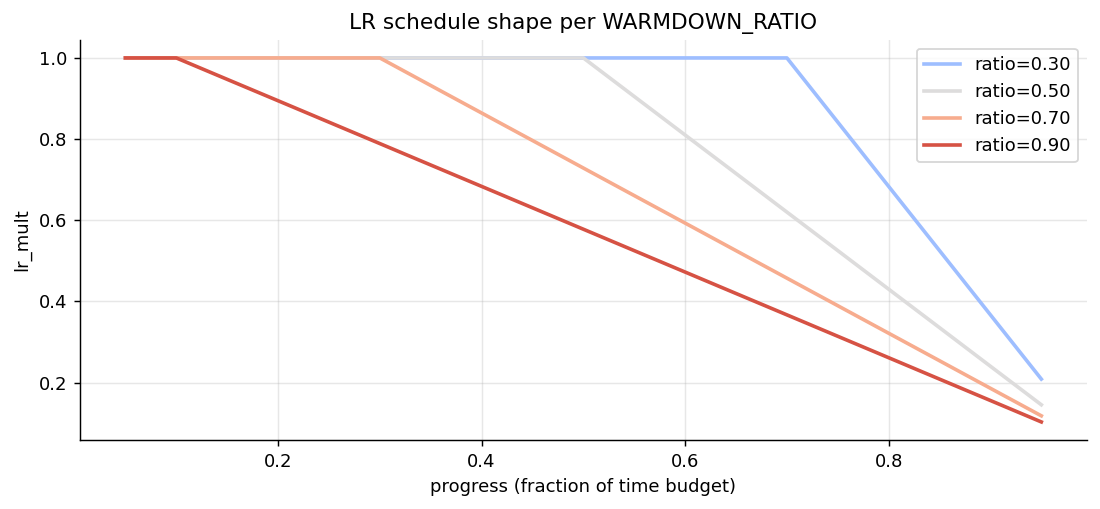

In [13]:
if sweep_df.empty:
    print("Skipping 8.3: no sweep data.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    prog_df = sweep_df[sweep_df["source"] == "progress"]
    ratios = sorted(prog_df["ratio"].dropna().unique())

    for r in ratios:
        sub = prog_df[prog_df["ratio"] == r].sort_values("progress")
        ax.plot(
            sub["progress"],
            sub["lr_mult"],
            label=f"ratio={r:.2f}",
            color=_ratio_color(r),
            linewidth=2,
        )

    ax.set_xlabel("progress (fraction of time budget)")
    ax.set_ylabel("lr_mult")
    ax.set_title("LR schedule shape per WARMDOWN_RATIO")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if SWEEP_PARENT is not None:
        plt.savefig(SWEEP_PARENT / "sweep_lr_schedules.png", bbox_inches="tight")
        print(f"Saved: {SWEEP_PARENT / 'sweep_lr_schedules.png'}")
    plt.show()

### 8.4 Final val_bpb vs ratio

The headline result in one glance. Uses the last milestone's uncapped `val_bpb` per run.

Saved: C:\Dev\AI\Training\autoresearch\output\2026-04-19_warmdown_sweep_2h\sweep_final_vs_ratio.png


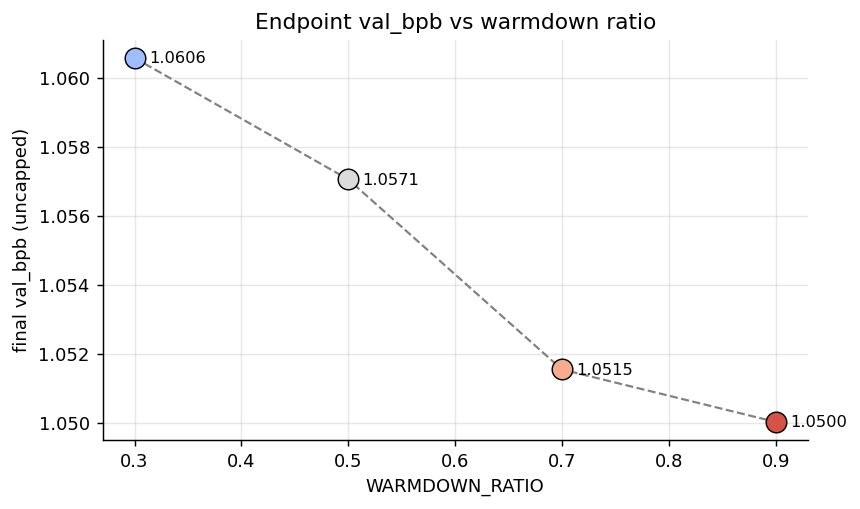

,ratio,val_bpb,num_steps,elapsed_seconds
0,0.3,1.060571,31257,7200.1
1,0.5,1.057050,28821,7200.1
2,0.7,1.051539,33223,7200.1
3,0.9,1.050018,34661,7200.2


In [14]:
if sweep_df.empty:
    print("Skipping 8.4: no sweep data.")
else:
    ms_df = sweep_df[sweep_df["source"] == "milestone"].copy()
    final = (
        ms_df.sort_values(["run_label", "elapsed_seconds"])
        .groupby("run_label")
        .tail(1)
        .sort_values("ratio")
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        final["ratio"],
        final["val_bpb"],
        color="gray",
        linestyle="--",
        linewidth=1.2,
        zorder=3,
    )
    for _, row in final.iterrows():
        ax.scatter(
            row["ratio"],
            row["val_bpb"],
            color=_ratio_color(row["ratio"]),
            s=130,
            edgecolor="black",
            linewidth=0.8,
            zorder=5,
        )
        ax.annotate(
            f"{row['val_bpb']:.4f}",
            (row["ratio"], row["val_bpb"]),
            textcoords="offset points",
            xytext=(8, -3),
            fontsize=9,
        )

    ax.set_xlabel("WARMDOWN_RATIO")
    ax.set_ylabel("final val_bpb (uncapped)")
    ax.set_title("Endpoint val_bpb vs warmdown ratio")
    ax.grid(True, alpha=0.3)
    if SWEEP_PARENT is not None:
        plt.savefig(SWEEP_PARENT / "sweep_final_vs_ratio.png", bbox_inches="tight")
        print(f"Saved: {SWEEP_PARENT / 'sweep_final_vs_ratio.png'}")
    plt.show()

    display(
        final[["ratio", "val_bpb", "num_steps", "elapsed_seconds"]].reset_index(
            drop=True
        )
    )

### 8.5 Milestone val_bpb grouped bars

Where the ratios diverge during training. Same source as 8.2's milestone markers, just grouped by milestone instead of plotted over time.

Saved: C:\Dev\AI\Training\autoresearch\output\2026-04-19_warmdown_sweep_2h\sweep_milestone_bars.png


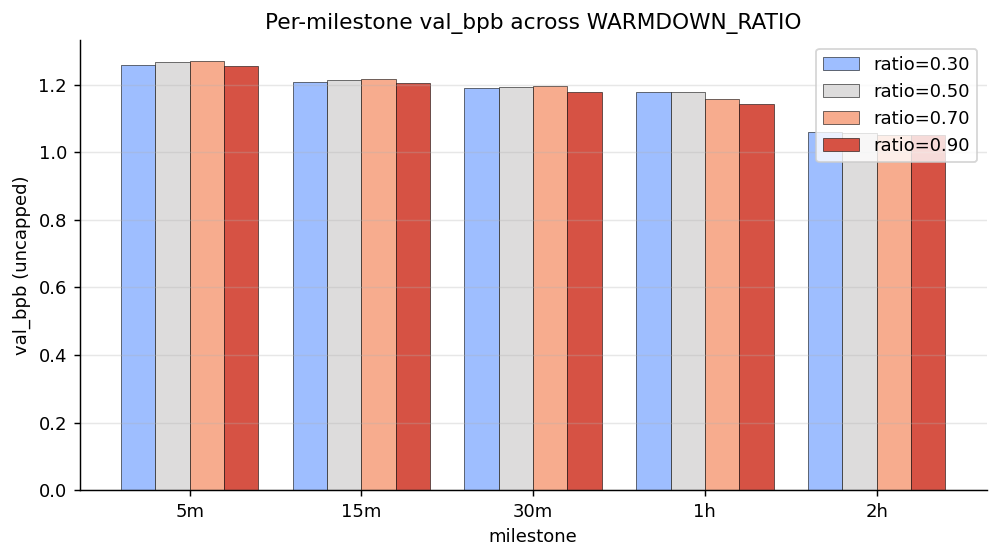

ratio,0.3,0.5,0.7,0.9
milestone,,,,
5m,1.2565,1.2674,1.2691,1.2537
15m,1.2066,1.2139,1.2150,1.2051
30m,1.1887,1.1917,1.1960,1.1775
1h,1.1772,1.1777,1.1568,1.1424
2h,1.0606,1.0570,1.0515,1.0500


In [15]:
if sweep_df.empty:
    print("Skipping 8.5: no sweep data.")
else:
    ms_df = sweep_df[sweep_df["source"] == "milestone"].copy()
    pivot = ms_df.pivot_table(index="milestone", columns="ratio", values="val_bpb")
    order = [l for l in LABELS if l in pivot.index]
    pivot = pivot.reindex(order)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    n_ratios = len(pivot.columns)
    bar_width = 0.8 / max(n_ratios, 1)
    x = np.arange(len(pivot.index))
    for i, r in enumerate(pivot.columns):
        offset = i * bar_width - (n_ratios - 1) * bar_width / 2
        ax.bar(
            x + offset,
            pivot[r],
            width=bar_width,
            color=_ratio_color(r),
            label=f"ratio={r:.2f}",
            edgecolor="black",
            linewidth=0.3,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_xlabel("milestone")
    ax.set_ylabel("val_bpb (uncapped)")
    ax.set_title("Per-milestone val_bpb across WARMDOWN_RATIO")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    if SWEEP_PARENT is not None:
        plt.savefig(SWEEP_PARENT / "sweep_milestone_bars.png", bbox_inches="tight")
        print(f"Saved: {SWEEP_PARENT / 'sweep_milestone_bars.png'}")
    plt.show()

    display(pivot.round(4))

### 8.6 Per-run small multiples

Each panel shows one run's training loss (gray, left axis) and capped `val_bpb` (ratio-coloured, right axis) against progress. Reveals per-run artifacts that the overlay might hide.

Saved: C:\Dev\AI\Training\autoresearch\output\2026-04-19_warmdown_sweep_2h\sweep_small_multiples.png


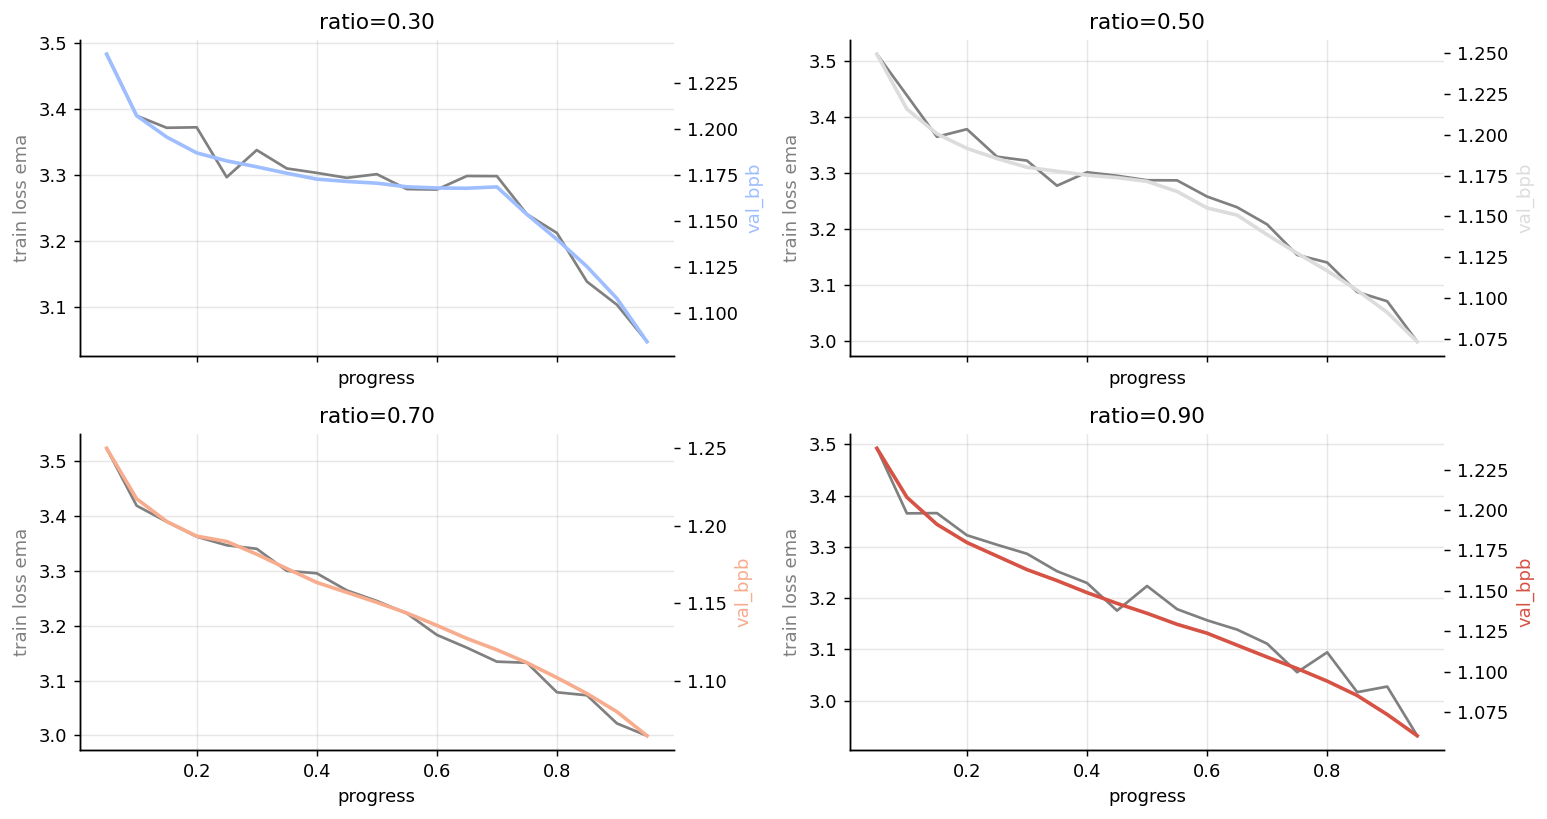

In [16]:
if sweep_df.empty:
    print("Skipping 8.6: no sweep data.")
else:
    prog_df = sweep_df[sweep_df["source"] == "progress"]
    ratios = sorted(prog_df["ratio"].dropna().unique())
    n = len(ratios)
    cols = 2
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3.2 * rows), sharex=True)
    axes = np.atleast_1d(axes).flatten()

    for i, r in enumerate(ratios):
        ax = axes[i]
        sub = prog_df[prog_df["ratio"] == r].sort_values("progress")
        ax2 = ax.twinx()
        ax.plot(
            sub["progress"],
            sub["train_loss_ema"],
            color="gray",
            linewidth=1.5,
            label="train loss ema",
        )
        ax2.plot(
            sub["progress"],
            sub["val_bpb"],
            color=_ratio_color(r),
            linewidth=2,
            label="val_bpb capped",
        )
        ax.set_title(f"ratio={r:.2f}")
        ax.set_xlabel("progress")
        ax.set_ylabel("train loss ema", color="gray")
        ax2.set_ylabel("val_bpb", color=_ratio_color(r))
        ax.grid(True, alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    if SWEEP_PARENT is not None:
        plt.savefig(SWEEP_PARENT / "sweep_small_multiples.png", bbox_inches="tight")
        print(f"Saved: {SWEEP_PARENT / 'sweep_small_multiples.png'}")
    plt.show()

### 8.7 Cross-run prompt comparison

Reads each run's `<milestone>_prompts.txt` and renders grouped prompt name -> milestone -> ratio. Writes two files:

- `<SWEEP_PARENT>/prompts.md` --- full cross-run layout (no truncation).
- `<run_dir>/prompts.md` --- per-run single-view layout (refreshed for every sweep child).

Cell output below is a truncated spot-check at the `2h` milestone.

In [17]:
if not SWEEP_DIRS:
    print("Skipping 8.7: no sweep dirs.")
else:
    sweep_md = _render_sweep_prompts_md(
        SWEEP_DIRS,
        LABELS,
        PROMPT_NAMES,
        ratio_of=_ratio_from_run_dir,
        truncate=None,
    )
    if SWEEP_PARENT is not None:
        (SWEEP_PARENT / "prompts.md").write_text(sweep_md, encoding="utf-8")
        print(f"Wrote: {SWEEP_PARENT / 'prompts.md'}  ({len(sweep_md):,} chars)")

    for d in SWEEP_DIRS:
        per_run = _render_prompts_md(d, LABELS, PROMPT_NAMES, truncate=None)
        (d / "prompts.md").write_text(per_run, encoding="utf-8")
        print(f"Wrote: {d / 'prompts.md'}  ({len(per_run):,} chars)")

    # In-cell spot-check at 2h, truncated
    spot = _render_sweep_prompts_md(
        SWEEP_DIRS,
        ["2h"],
        PROMPT_NAMES,
        ratio_of=_ratio_from_run_dir,
        truncate=500,
    )
    display(Markdown(spot))

Wrote: C:\Dev\AI\Training\autoresearch\output\2026-04-19_warmdown_sweep_2h\prompts.md  (123,416 chars)
Wrote: C:\Dev\AI\Training\autoresearch\output\2026-04-19_2h_warmdown_0.30_run\prompts.md  (29,866 chars)
Wrote: C:\Dev\AI\Training\autoresearch\output\2026-04-19_2h_warmdown_0.50_run\prompts.md  (30,891 chars)
Wrote: C:\Dev\AI\Training\autoresearch\output\2026-04-19_2h_warmdown_0.70_run\prompts.md  (30,223 chars)
Wrote: C:\Dev\AI\Training\autoresearch\output\2026-04-19_2h_warmdown_0.90_run\prompts.md  (30,437 chars)


# Sweep prompt outputs

Runs (ordered by ratio):

- `2026-04-19_2h_warmdown_0.30_run` --- WARMDOWN_RATIO=0.3
- `2026-04-19_2h_warmdown_0.50_run` --- WARMDOWN_RATIO=0.5
- `2026-04-19_2h_warmdown_0.70_run` --- WARMDOWN_RATIO=0.7
- `2026-04-19_2h_warmdown_0.90_run` --- WARMDOWN_RATIO=0.9

## `plain_continuation`

### 2h

**WARMDOWN_RATIO=0.3**

```text
The old man walked slowly toward the river and the river finally came down. It was all the small wooden boat striking the river, and they would fly and fly and soo... The man is now still waiting.

She is an exorbitantly agile, the man has never been seen as a car, and it has been a long- and short-, long day.

If the river is gone for, then there is no way in which to go to the old man to see a river. If you are still looking for an area you can take a lot longer to do then go straight north...
```

**WARMDOWN_RATIO=0.5**

```text
The old man walked slowly toward the river and the sun shining towards the waterfall. Some of us had to stay near the river, or where it was now. It seems like these were the beginning of that time.

Suggested the following items:

Discovered over the centuries, the people who were witnesses and their families took care of this and it is now. Now the people who lived up close are, and there is no way in which people who lived up close have to overcome their lives.

Carol and her husband, who ...
```

**WARMDOWN_RATIO=0.7**

```text
The old man walked slowly toward the river and the sun was the first person to land on the water
Looking back at the water, there was a goofy and white pine tree of life that could have died.
In an accident, at least two women died over the age of 18 who were injured, and their son was killed by a disease of a mother. Now the mother would lose all her energy, and a mother could lose her. Now who died?
The problem may be that the mother was injured and her son was killed. Some were born with w...
```

**WARMDOWN_RATIO=0.9**

```text
The old man walked slowly toward the river and the man walked fast. It would have been quite difficult due to time when the man moved there and would walk almost instantly and take more than an hour of walk and the man was not an effective man to man. The man was the one man walked fast. I'm not worried, my man walking slowly and it looked like. Now I'm the old man walked, and I'm very careful when my man step back and my man walked.
To me this might be fun to tell your man how long after you...
```

## `factual_fragment`

### 2h

**WARMDOWN_RATIO=0.3**

```text
The capital of France is Paris, and the population of the Paris army in Europe is now inextricably linked to the country. Lord Paris's enemies are not just a small town; they're a village surrounded by two of them who live in two places in front of their fellow. In fact, they're usually living in two buildings: the city of Paris with a very poor people, including Jordan Marks, who live on the hovers and, in a small city with many of them (i.e., many buildings) is now no exception. Lord Paris ...
```

**WARMDOWN_RATIO=0.5**

```text
The capital of France is Paris, and the population of the Paris army in Europe is now in this, but the country's population is changing the nation's way. The first French forces were invoicing the French government of the city as well as the Dutch province, whose population is continuing throughout the French. In fact, they were very similar – they first made it into France during the 14th century by a Swedish lawyer, Horachians and local governments, in 1516.
At the time of the invocation, t...
```

**WARMDOWN_RATIO=0.7**

```text
The capital of France is Paris, and the population of the country needs this. At the present time, this, for the first time in France, the Paris Church, and Ireland.
The Paris Church was the only building of a large-scale infrastructure development of Paris. The town of Freak, is of great importance to Polish government. Paris was already built on a promising community of people, including Prussian people, to facilitate the provision of government and economic services in areas similar to the...
```

**WARMDOWN_RATIO=0.9**

```text
The capital of France is Paris, and the population of the Parisians is in Europe. Most of this, but the country is in France's Land
The Rise of Non-Korbigmans: Land as well as some of them cancel out. They can't be bought for sale. They can't be handed to other country
I was reading that one last thing about Paris and this is because I was very familiar with the idea of how the local government is able to stop them from getting there. There are many governments, some of these governments that...
```

## `longitudinal_anchor`

### 2h

**WARMDOWN_RATIO=0.3**

```text
In one sentence, the meaning of life is based on a particular emotion and a particular emotion. When a person has a emotion, they can tell him that it is an emotion. He can be depressing for the person of choice. When a person thinks a person desperately needs to leave his loved ones. When a person feels the need to leave out his loved ones. When a person is a need to leave out his loved ones. When a person thinks a person is a need to leave, he can lead his loved ones. When a person thinks s...
```

**WARMDOWN_RATIO=0.5**

```text
In one sentence, the meaning of life is based on a particular emotion and a narrative. When a word comes up – we may not understand or refrain – an meaning that is a symbol. Some people believe life is the meaning of life. When a word comes up, a meaning is a meaning from a specific emotion. When a word comes up – in other words, a word comes up – in other words, a meaning is a meaning from a meaning from a particular emotion.
Only the same interpretations – some people may not understand bec...
```

**WARMDOWN_RATIO=0.7**

```text
In one sentence, the meaning of life is based on a particular reason, and often, the truth is that they are not true.
A scientist at Puellert University in Boston is arguing that they believe life is not something of a science and it is not a science and not God.
Scientists claim that they can prove their wrong hypothesis that existence will be something that may be true.
Could be so counterproductive to believing truth, it isn't something of a science, the same way life is not a science, it ...
```

**WARMDOWN_RATIO=0.9**

```text
In one sentence, the meaning of life is based on a particular meta-analysis. While it may seem to be similarly obvious, life is still too harsh to develop as you make progress. Many people who believe life is the most important thing. When you are thinking of living a long life, then life isn't always an answer to the question: ‪ Why is life and life important? ” ” ” Life as well as life is considered the most significant part of the global population. ‪ And life as well as life itself, there...
```

## `structurally_awkward`

### 2h

**WARMDOWN_RATIO=0.3**

```text
Despite the fact that however, the reason why because of their poor quality, such that their production is actually poor quality or they are just low quality, is just in some way very much a fact that is very poorly priced, and they are quite hard to compare and contrast both. However, they have certainly been very successful people as they were a little boring, that, and you still aren't sure what this is. It doesn't matter whether that is a fact, that you are really trying to buy new equipm...
```

**WARMDOWN_RATIO=0.5**

```text
Despite the fact that however, the reason why because a lot of people still have that fearless of fear, such as the fact that they are now in a public place, they were afraid to justify what they already know and expect and what it means.

When I look back at the current state of public speaking, people have been saying that you and your community will not be able to speak and understand what this means. It was when a state that fears you and your audience are really trying to understand is a...
```

**WARMDOWN_RATIO=0.7**

```text
Despite the fact that however, the reason why because of such an extreme degree of extreme fear has been the only danger we see over the long term, is given to some fear that we are still presenting in the situations where we are not fully prepared from it. Such situations are simply an emergency response that can be easily taken away by a family situation where you and your family are not prepared from. When we are able to react in real time when a difficult situation becomes a problem, we a...
```

**WARMDOWN_RATIO=0.9**

```text
Despite the fact that however, the reason why because of their poor eyesight. They never thought of the fact that we were all just like people, we could see some more about how we have come to believe in what is happening, and how and why it goes.

When I look back at the original question I came across, people have been saying "toucan" to me and I think "toucan" to go. When it comes to that question. While people have been saying they do nothing at all! Even though it's the fact that it's a ...
```

## `anomaly_lure`

### 2h

**WARMDOWN_RATIO=0.3**

```text
Ground control to Major Snorf, with its own approach, is a big asset, to the development of a more comprehensive and productatic way of communication. It's an extremely reliable, reliable way to manage and manage communications.
The problem is that it is the communication of the team and its decision-making abilities. This, at the very moment, leads to the development of a more strategic, well-opted approach.
This is in contrast to the competitiveness of the approach, however, to the communic...
```

**WARMDOWN_RATIO=0.5**

```text
Ground control to Major Snorf, with its overseas gait and its large, powerful handwrapped grip. In it's very common name: Gill, Sonar (the Nephroeus) – Gill, Sonar (the native Nephroeus), and Sonar (the Latin native name of Gilliparpis). Gill's large grip is in the most general area of the grip, giving him a general sense of control of the snake as they move and hide.

So when you take the "hide and the grip" to your new location you will see, you will see a gait and a reelsh gait while your ...
```

**WARMDOWN_RATIO=0.7**

```text
Ground control to Major Snorf, a reptilian who led the Czech Academy's successful convoyed Razorovski Monster, was reassured by the Monster 6'Neel of the Ground of the Casserole when he was born in the Monster 6'Neel of Mountain. He was well known of its most distinguishable head, but in addition it was a very capable masheddowder.
Her first step is to teach young mashes about food, the story of Ricca, that includes food and shelter from the effects of human activities, and how he went to reh...
```

**WARMDOWN_RATIO=0.9**

```text
Ground control to Major Snorf, with its latest

Follow us on Twitter

Ground-balancing is an intriguing way of enhancing safety features in an upcoming, ever-loving NPR Senator.

NPR Sensing

Ground-balancing is the method of building smart, safe, comfortable clothing that has undergone advanced safety testing. Eco-friendly technology with its exceptional weather-fighting capabilities and advanced features make this innovative approach a must-have for every gamer. From safety features and acc...
```

## `signature`

### 2h

**WARMDOWN_RATIO=0.3**

```text
Once upon a time there was a small town called Latucci or Mahokai and, in Tokhur, the town lived comfortably in the region. Based on this experience, there would have been some unbelievable weather conditions like wet, humid, and dry conditions when there was little rain, sunny conditions, or poor conditions.

At Latucci, there was little rain near the town, even though its windshield was strong enough. As a result, the town turned to a very cold day and was constantly running in the same spo...
```

**WARMDOWN_RATIO=0.5**

```text
Once upon a time there was a small woman named Lynx, married with friends who had lived in an apartment living in a place filled with different cultures. Lynx lived up to nine months before marrying out in the neighborhood, finding new ways to express themselves in his life through a lens. He was diagnosed with cancer, learning about his life through diet and socializing with others, and being an astonished little girl named her who always loved nature. However, he couldn't help but feel alon...
```

**WARMDOWN_RATIO=0.7**

```text
Once upon a time there was a small group of people from all over the world who seemed to take a break in the clouds and enjoyed different tastes and tastes. This was what they had called "Ever since we had been thrown around and seen some of them peeking out and making puddles.
There, I am a napkin, who is a master of reading fluency. I think it is a good idea to explain things to the whole audience as well. I know that we can always listen to what we learn in the first hours of the day, beca...
```

**WARMDOWN_RATIO=0.9**

```text
Once upon a time there was a small town called Latucci, lived two munitions, one of which became known as the Princes and the other a mad. The Princes had friends who loved sharing stories and stories about different cultures and cultures in different countries. However, as they weren't always there, these friends took part in learning about each other, especially among the people who made them feel loved sharing experiences and sharing stories.
One day, while browsing for more at first glanc...
```

## `continuation`

### 2h

**WARMDOWN_RATIO=0.3**

```text
The instructions were clear until line seven: I found it funny that the Irwinian Ferraranovie performed similarly to some of their mothers, but it was only a matter of thinking, as it were just a way to keep my family company safe and secure. This is the reason I was born in 1879. It was supposed to be a very real life experience, but had not been the first to survive as many children as it was. I never heard that people were willing to play and play with games to help get their children out ...
```

**WARMDOWN_RATIO=0.5**

```text
The instructions were clear until line seven: IT IS AWN, IT IS A FRONE. THE EATILY WEEK DISPOSED. Last time I was reading a book called "The Venice Of Firebird Johnshaw". And in this book, you are now describing a very old way of seeing the life of the firebird Johnshaw. As I saw in our previous book, though, you are not wrong about it, because you were wrong. In the next chapter on The Venice Of Firebird Johnshaw the reader were probably wrong, but the texts are a mixture of words and pengui...
```

**WARMDOWN_RATIO=0.7**

```text
The instructions were clear until line seven: I found it easy to pull the slopes towards my eyes. The trick was to quickly turn on my desk. For the length of the slopes, if there were more, I would have just taken the slopes. Framing the slopes towards the sun, I added a new 2 3 cm 8 4 cm 12 cm 6 cm layer, and then let the slopes reach the sun. All three had 55.5 cm. I then used a 2 to 5cm 8 2 3 1. I put 18 6 cm and 45 2 5 3 2. I re-approached what was set on the slope to the sun, and it went...
```

**WARMDOWN_RATIO=0.9**

```text
The instructions were clear until line seven: A. Dungan

B. Gerald F. Crick

C. Ford

Answer: B. Dungan

D. Lloyd

D. Jamie G. Rick

Answer: C

Lewis Armit

Answer: G Rick

D. Ford

Answer: B. Dungan

Answer: C

H

Lewis Armit

Answer: B

Lewis Armit

Answer: L

Hewis Armit

Answer: H

Lewis Armit

Answer: H

Hewis Armit

Answer: H

Lewis Armit

Answer: B

Lewis Armit

Answer: H

Lewis Armit

Answer: H

Lewis Armit

Answer: H

Hewis Armit

Answer: H

Lewis Armit

Answer: Her

Her

Hewitzing

...
```
